In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split

In [97]:
pd.options.display.float_format = '{:.2f}'.format

# Dataset loading

In [98]:
data_path = r"C:\Users\erica\Documents\Mestrado\Projetos\Advanced_DS\Ames_Housing_Project\data\raw\AmesHousing.csv"
df = pd.read_csv(data_path)
pd.set_option('display.max_columns', None)
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.00,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.00,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.00,Unf,0.00,441.00,1080.00,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.00,0.00,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.00,Fin,2.00,528.00,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.00,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.00,TA,TA,CBlock,TA,TA,No,ALQ,923.00,Unf,0.00,406.00,1329.00,GasA,TA,Y,SBrkr,1329,0,0,1329,0.00,0.00,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.00,Unf,1.00,312.00,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.00,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.00,Gd,TA,CBlock,TA,TA,No,ALQ,1065.00,Unf,0.00,1045.00,2110.00,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.00,0.00,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.00,Fin,2.00,522.00,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.00,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,GLQ,791.00,Unf,0.00,137.00,928.00,GasA,Gd,Y,SBrkr,928,701,0,1629,0.00,0.00,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.00,Fin,2.00,482.00,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Exploratory Data Analisys

## Descriptive statistics

In [101]:
df.info()

<class 'pandas.DataFrame'>
Index: 2051 entries, 2210 to 860
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2051 non-null   int64  
 1   PID              2051 non-null   int64  
 2   MS SubClass      2051 non-null   int64  
 3   MS Zoning        2051 non-null   str    
 4   Lot Frontage     1704 non-null   float64
 5   Lot Area         2051 non-null   int64  
 6   Street           2051 non-null   str    
 7   Alley            147 non-null    str    
 8   Lot Shape        2051 non-null   str    
 9   Land Contour     2051 non-null   str    
 10  Utilities        2051 non-null   str    
 11  Lot Config       2051 non-null   str    
 12  Land Slope       2051 non-null   str    
 13  Neighborhood     2051 non-null   str    
 14  Condition 1      2051 non-null   str    
 15  Condition 2      2051 non-null   str    
 16  Bldg Type        2051 non-null   str    
 17  House Style      2051 non-nu

In [102]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2051.00,2051.00,2051.00,1704.00,2051.00,2051.00,2051.00,2051.00,2051.00,2037.00,2050.00,2050.00,2050.00,2050.00,2051.00,2051.00,2051.00,2051.00,2050.00,2050.00,2051.00,2051.00,2051.00,2051.00,2051.00,2051.00,1940.00,2050.00,2050.00,2051.00,2051.00,2051.00,2051.00,2051.00,2051.00,2051.00,2051.00,2051.00,2051.00
mean,1468.06,714207158.37,57.63,69.35,10179.89,6.05,5.59,1969.98,1983.81,99.83,443.16,49.43,556.37,1048.96,1156.80,336.35,4.47,1497.63,0.43,0.06,1.56,0.37,2.86,1.05,6.43,0.59,1977.22,1.75,469.28,94.45,47.54,25.21,2.62,15.84,2.52,61.57,6.17,2007.79,178641.25
std,844.89,188649750.62,43.03,23.70,8427.01,1.39,1.12,30.40,20.76,175.82,454.65,169.43,437.26,441.23,389.30,429.72,45.97,514.94,0.53,0.24,0.55,0.50,0.83,0.22,1.59,0.66,25.08,0.75,213.62,125.05,68.10,67.40,25.83,54.30,38.08,660.89,2.69,1.32,78030.41
min,1.00,526301100.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,0.00,0.00,334.00,0.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,1896.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,12789.00
25%,738.50,528482110.00,20.00,58.00,7419.50,5.00,5.00,1953.00,1965.00,0.00,0.00,0.00,216.25,785.00,877.00,0.00,0.00,1121.00,0.00,0.00,1.00,0.00,2.00,1.00,5.00,0.00,1960.00,1.00,319.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2007.00,129000.00
50%,1474.00,535454050.00,50.00,68.00,9360.00,6.00,5.00,1972.00,1992.00,0.00,375.50,0.00,460.00,988.00,1082.00,0.00,0.00,1440.00,0.00,0.00,2.00,0.00,3.00,1.00,6.00,1.00,1978.00,2.00,478.00,0.00,26.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,160000.00
75%,2196.50,907187020.00,70.00,80.00,11517.50,7.00,6.00,1999.00,2003.00,158.00,731.25,0.00,796.00,1289.50,1382.50,701.00,0.00,1741.00,1.00,0.00,2.00,1.00,3.00,1.00,7.00,1.00,2000.00,2.00,576.00,168.00,70.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,210000.00
max,2929.00,924152030.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1290.00,5644.00,1526.00,2336.00,6110.00,5095.00,2065.00,1064.00,5642.00,3.00,2.00,4.00,2.00,8.00,3.00,15.00,4.00,2010.00,4.00,1488.00,870.00,742.00,1012.00,508.00,410.00,800.00,17000.00,12.00,2010.00,755000.00


In [103]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 2051
Quantidade de colunas: 82


## Tabelas

In [104]:
summary_table = pd.DataFrame({
    'Num of Values': df.count(),
    '% of Missing Values': df.isnull().mean() * 100,
    'Unique Values (Categorical)': df.select_dtypes(include=['object', 'string']).nunique(),
    'Mean (Numerical)': df.select_dtypes(include='number').mean(),
    'Python Type': df.dtypes,
})

pd.set_option('display.max_rows', None)
summary_table


,Num of Values,% of Missing Values,Unique Values (Categorical),Mean (Numerical),Python Type
1st Flr SF,2051,0.00,NaN,1156.80,int64
2nd Flr SF,2051,0.00,NaN,336.35,int64
3Ssn Porch,2051,0.00,NaN,2.62,int64
Alley,147,92.83,2.00,NaN,str
Bedroom AbvGr,2051,0.00,NaN,2.86,int64
Bldg Type,2051,0.00,5.00,NaN,str
Bsmt Cond,1998,2.58,5.00,NaN,str
Bsmt Exposure,1996,2.68,4.00,NaN,str
Bsmt Full Bath,2050,0.05,NaN,0.43,float64
Bsmt Half Bath,2050,0.05,NaN,0.06,float64


### Variáveis numéricas

In [105]:
numerical_cols = df.select_dtypes(include='number').columns

In [106]:
numerical_summary = pd.DataFrame({
    'Tipo': df[numerical_cols].dtypes,
    'Média': df[numerical_cols].mean(),
    'Mediana': df[numerical_cols].median(),
    'Desvio Padrão': df[numerical_cols].std(),
    'Mínimo': df[numerical_cols].min(),
    'Máximo': df[numerical_cols].max(),
})

numerical_summary

,Tipo,Média,Mediana,Desvio Padrão,Mínimo,Máximo
Order,int64,1468.06,1474.00,844.89,1.00,2929.00
PID,int64,714207158.37,535454050.00,188649750.62,526301100.00,924152030.00
MS SubClass,int64,57.63,50.00,43.03,20.00,190.00
Lot Frontage,float64,69.35,68.00,23.70,21.00,313.00
Lot Area,int64,10179.89,9360.00,8427.01,1300.00,215245.00
Overall Qual,int64,6.05,6.00,1.39,1.00,10.00
Overall Cond,int64,5.59,5.00,1.12,1.00,9.00
Year Built,int64,1969.98,1972.00,30.40,1872.00,2010.00
Year Remod/Add,int64,1983.81,1992.00,20.76,1950.00,2010.00
Mas Vnr Area,float64,99.83,0.00,175.82,0.00,1290.00


In [107]:
numerical_summary.sort_values(by='Desvio Padrão', ascending=False)

,Tipo,Média,Mediana,Desvio Padrão,Mínimo,Máximo
PID,int64,714207158.37,535454050.00,188649750.62,526301100.00,924152030.00
SalePrice,int64,178641.25,160000.00,78030.41,12789.00,755000.00
Lot Area,int64,10179.89,9360.00,8427.01,1300.00,215245.00
Order,int64,1468.06,1474.00,844.89,1.00,2929.00
Misc Val,int64,61.57,0.00,660.89,0.00,17000.00
Gr Liv Area,int64,1497.63,1440.00,514.94,334.00,5642.00
BsmtFin SF 1,float64,443.16,375.50,454.65,0.00,5644.00
Total Bsmt SF,float64,1048.96,988.00,441.23,0.00,6110.00
Bsmt Unf SF,float64,556.37,460.00,437.26,0.00,2336.00
2nd Flr SF,int64,336.35,0.00,429.72,0.00,2065.00


### Variáveis Categóricas

In [108]:
catergorical_cols = df.select_dtypes(include=['object', 'string']).columns

In [109]:
categorical_summary = pd.DataFrame({
    'Valores Únicos': df[catergorical_cols].nunique(),
    'Valor Mais Frequente': df[catergorical_cols].mode().iloc[0],
    'Frequência do Valor Mais Frequente': df[catergorical_cols].apply(lambda x: x.value_counts().iloc[0]),
    'Porcentagem do Valor Mais Frequente': df[catergorical_cols].apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100)
})
categorical_summary.sort_values(by='Valores Únicos', ascending=False)

,Valores Únicos,Valor Mais Frequente,Frequência do Valor Mais Frequente,Porcentagem do Valor Mais Frequente
Neighborhood,28,NAmes,322,15.70
Exterior 1st,15,VinylSd,698,34.03
Exterior 2nd,15,VinylSd,693,33.79
Condition 1,9,Norm,1757,85.67
Sale Type,9,WD,1790,87.27
House Style,8,1Story,1039,50.66
Functional,8,Typ,1909,93.08
Condition 2,8,Norm,2032,99.07
MS Zoning,7,RL,1579,76.99
Roof Matl,7,CompShg,2019,98.44


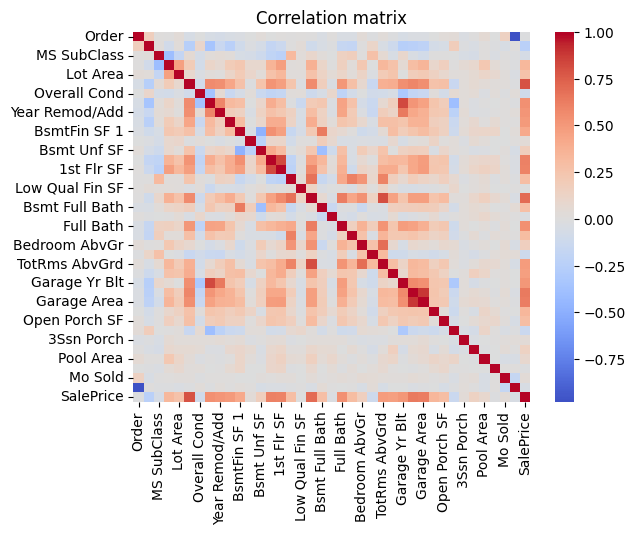

In [132]:
plt.figure()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

# cria um mapa de calor para visualizar as correlações entre as variáveis numéricas,
# usando a paleta de cores "coolwarm" para destacar as correlações positivas e negativas.
# O parâmetro center=0 centraliza a escala de cores em torno de zero, facilitando a identificação de correlações fortes e fracas.

In [133]:
corr_target = corr['SalePrice'].sort_values(ascending=False)
corr_target
# exibe as correlações da variável alvo 'SalePrice' com as demais variáveis numéricas,
#  ordenadas de forma decrescente para identificar quais variáveis têm maior correlação com o preço de venda.

SalePrice          1.00
Overall Qual       0.79
Gr Liv Area        0.70
Garage Cars        0.64
Garage Area        0.63
Total Bsmt SF      0.61
1st Flr SF         0.61
Full Bath          0.54
Year Built         0.54
Year Remod/Add     0.51
Garage Yr Blt      0.51
Mas Vnr Area       0.50
TotRms AbvGrd      0.48
Fireplaces         0.47
BsmtFin SF 1       0.42
Wood Deck SF       0.34
Lot Frontage       0.33
Half Bath          0.30
Open Porch SF      0.29
2nd Flr SF         0.29
Bsmt Full Bath     0.29
Lot Area           0.26
Bsmt Unf SF        0.17
Bedroom AbvGr      0.16
Screen Porch       0.14
Pool Area          0.08
BsmtFin SF 2       0.04
3Ssn Porch         0.04
Mo Sold            0.04
Low Qual Fin SF   -0.01
Order             -0.01
Misc Val          -0.02
Bsmt Half Bath    -0.02
Yr Sold           -0.05
MS SubClass       -0.06
Overall Cond      -0.10
Kitchen AbvGr     -0.12
Enclosed Porch    -0.14
PID               -0.24
Name: SalePrice, dtype: float64

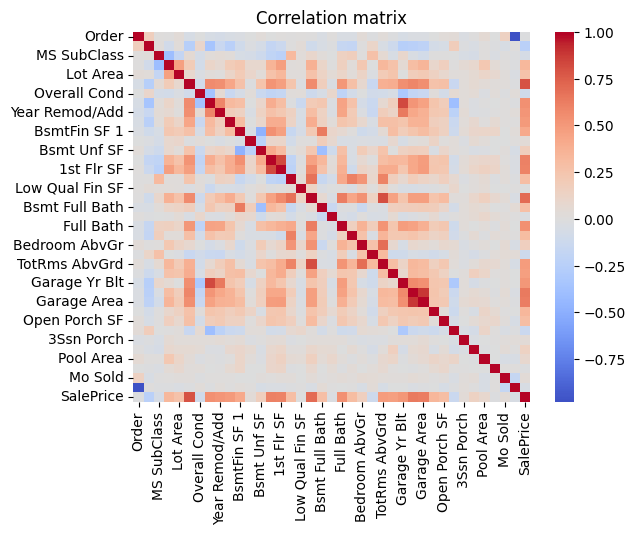

In [134]:
plt.figure()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

# cria um mapa de calor para visualizar as correlações entre as variáveis numéricas

In [135]:
pd.DataFrame(corr_target).T

,SalePrice,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Full Bath,Year Built,Year Remod/Add,Garage Yr Blt,Mas Vnr Area,TotRms AbvGrd,Fireplaces,BsmtFin SF 1,Wood Deck SF,Lot Frontage,Half Bath,Open Porch SF,2nd Flr SF,Bsmt Full Bath,Lot Area,Bsmt Unf SF,Bedroom AbvGr,Screen Porch,Pool Area,BsmtFin SF 2,3Ssn Porch,Mo Sold,Low Qual Fin SF,Order,Misc Val,Bsmt Half Bath,Yr Sold,MS SubClass,Overall Cond,Kitchen AbvGr,Enclosed Porch,PID
SalePrice,1.00,0.79,0.70,0.64,0.63,0.61,0.61,0.54,0.54,0.51,0.51,0.50,0.48,0.47,0.42,0.34,0.33,0.30,0.29,0.29,0.29,0.26,0.17,0.16,0.14,0.08,0.04,0.04,0.04,-0.01,-0.01,-0.02,-0.02,-0.05,-0.06,-0.10,-0.12,-0.14,-0.24


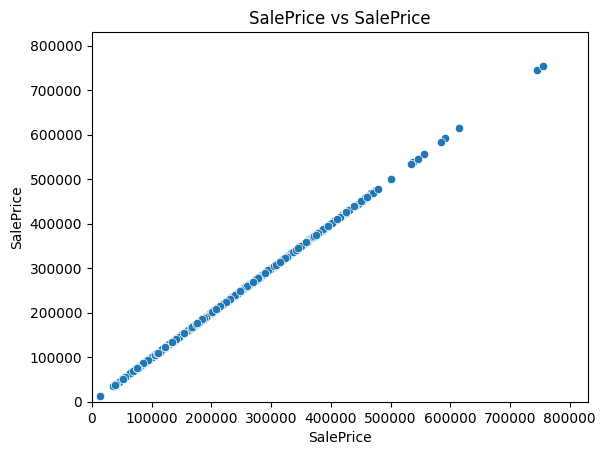

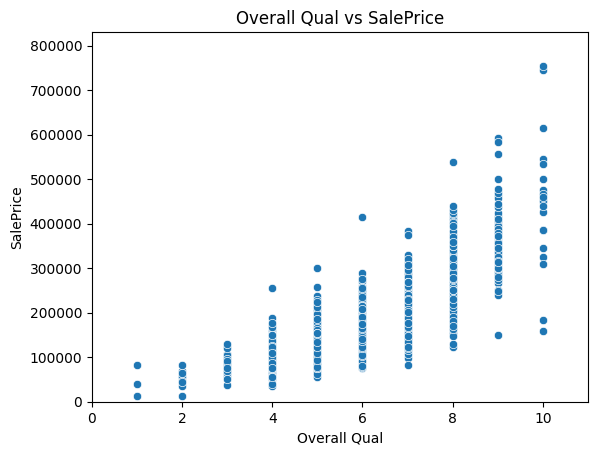

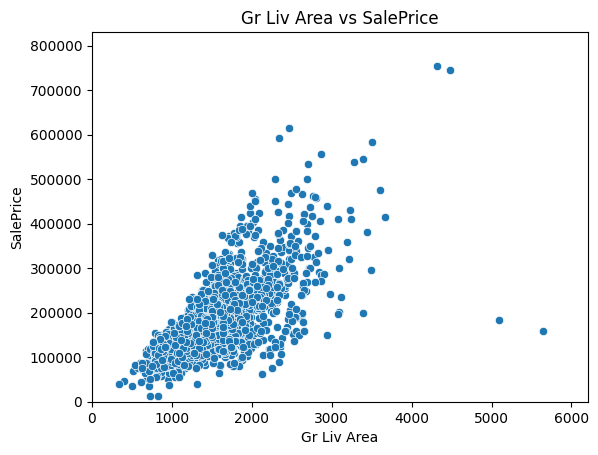

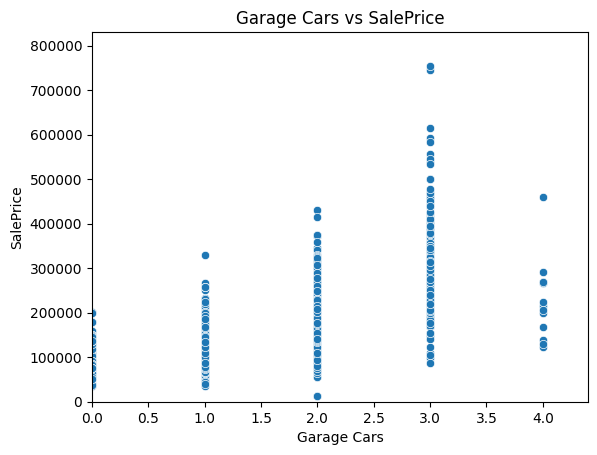

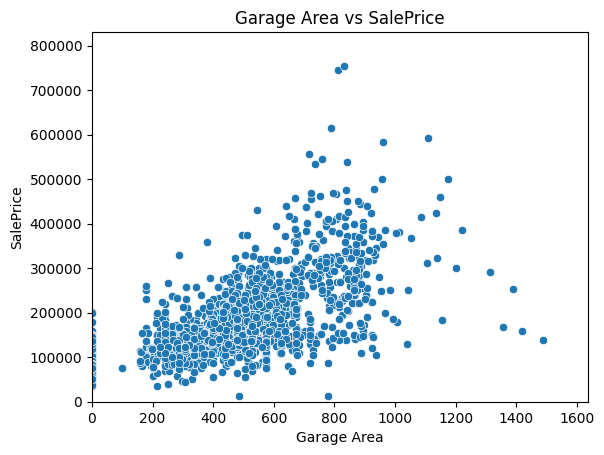

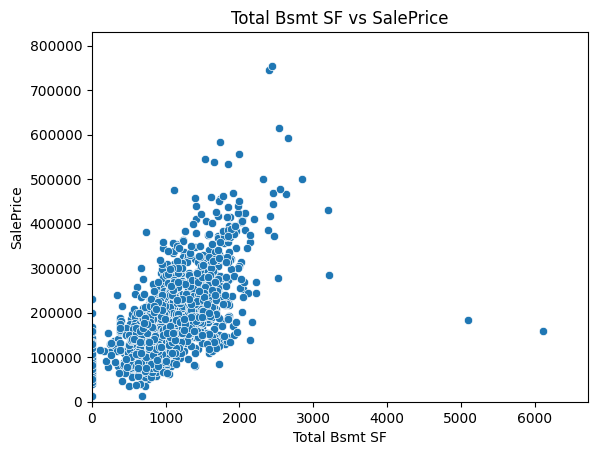

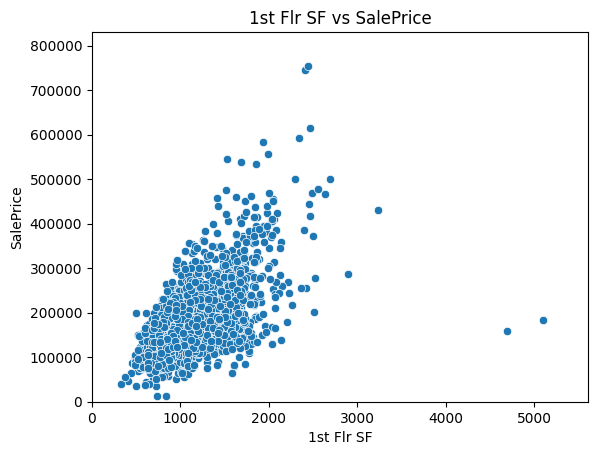

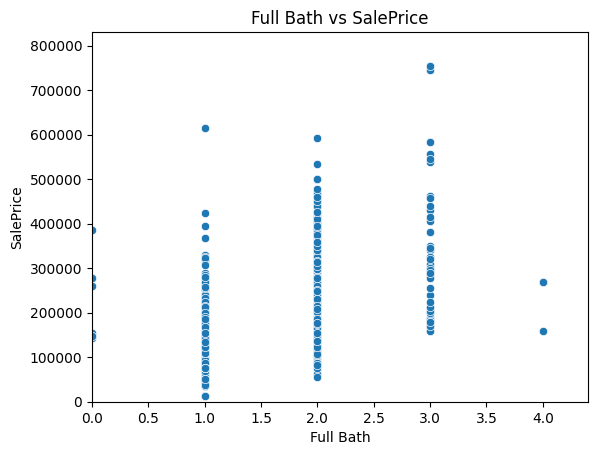

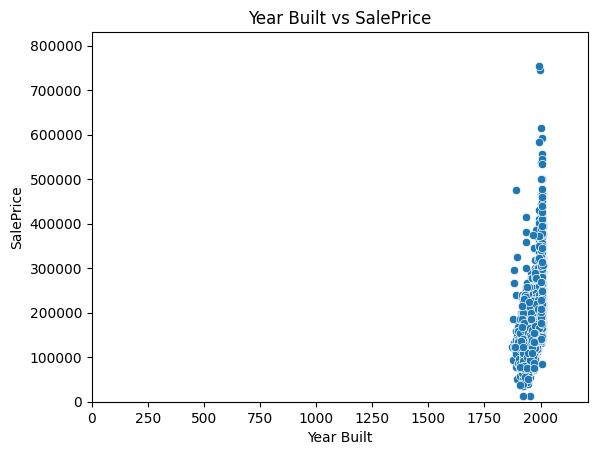

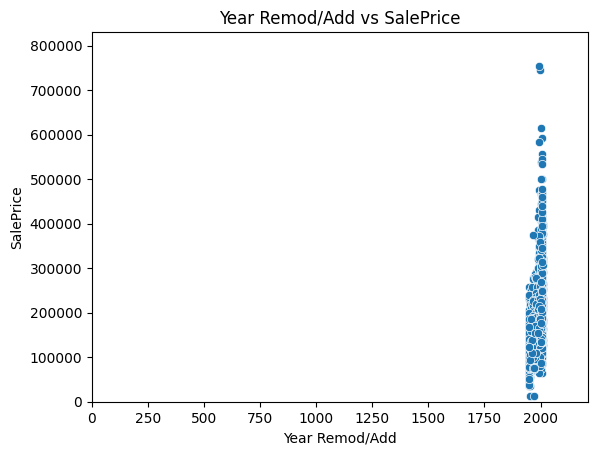

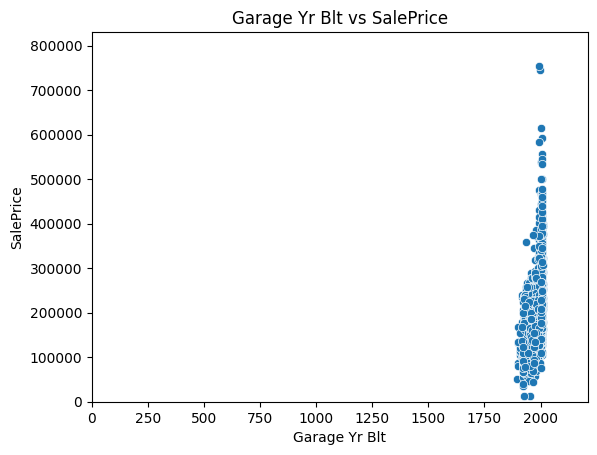

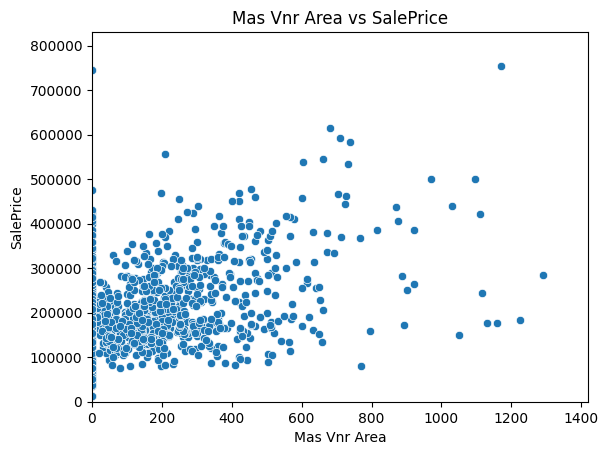

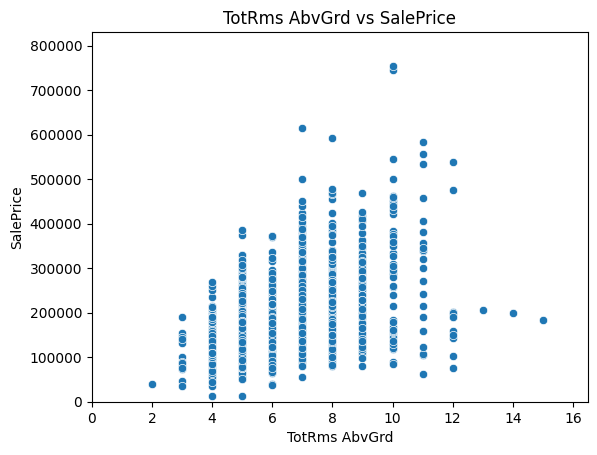

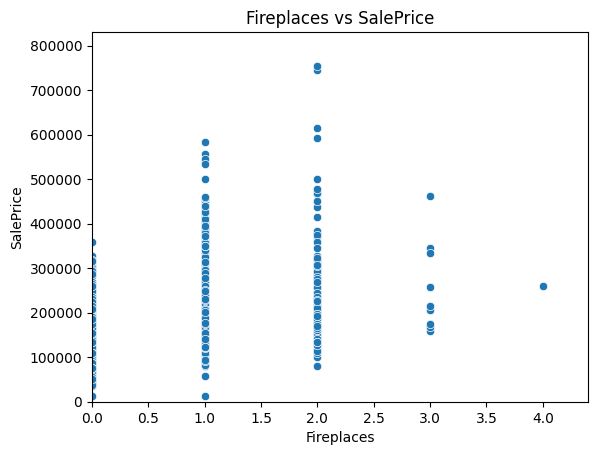

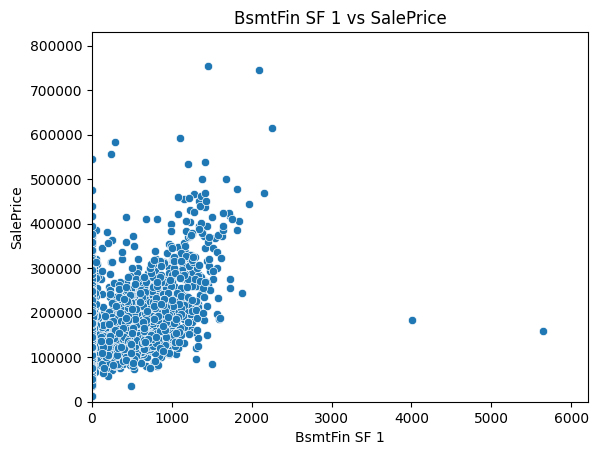

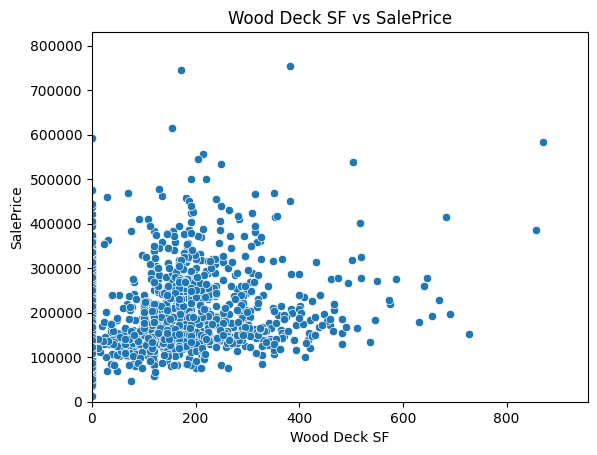

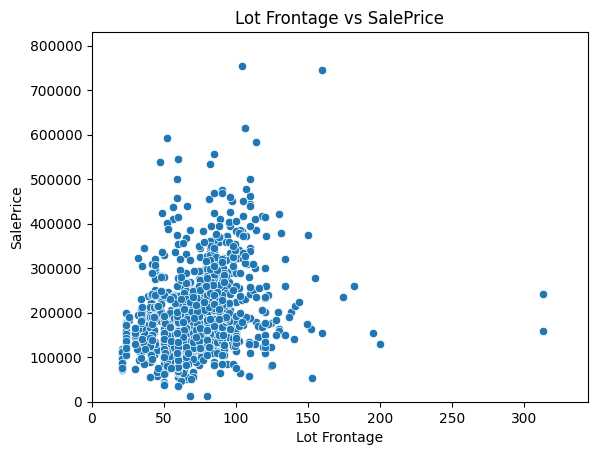

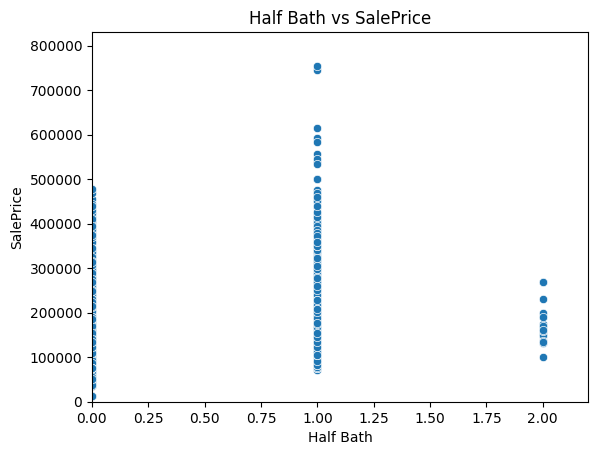

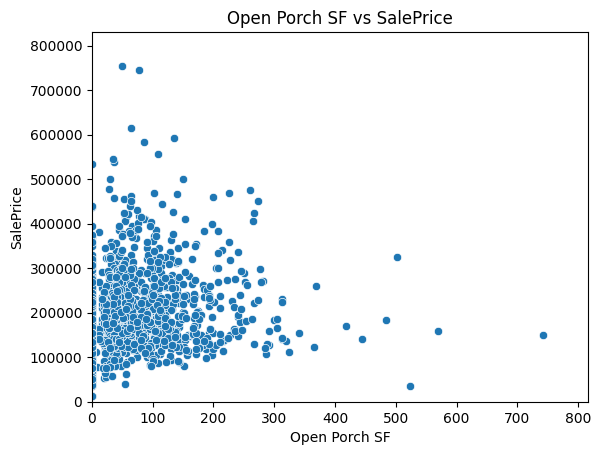

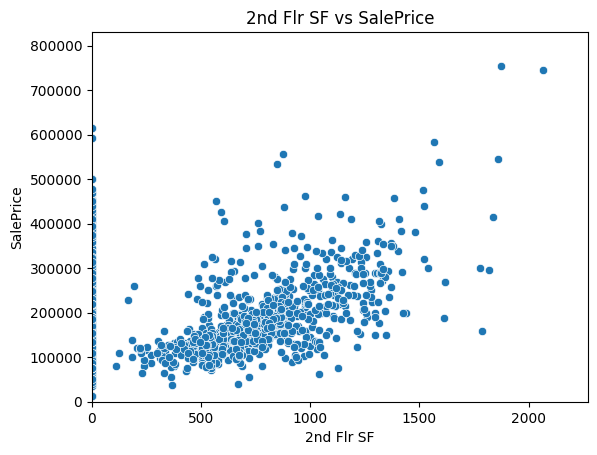

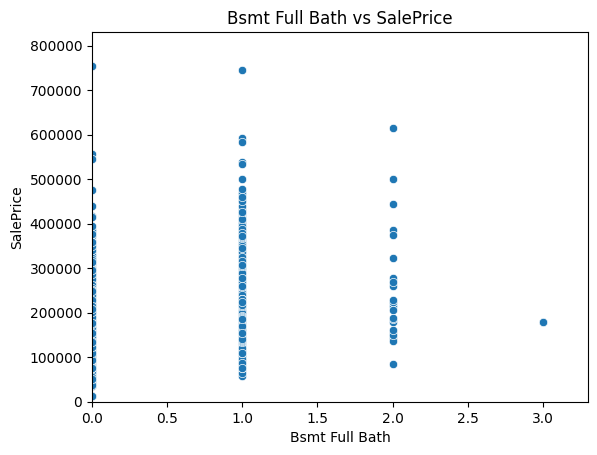

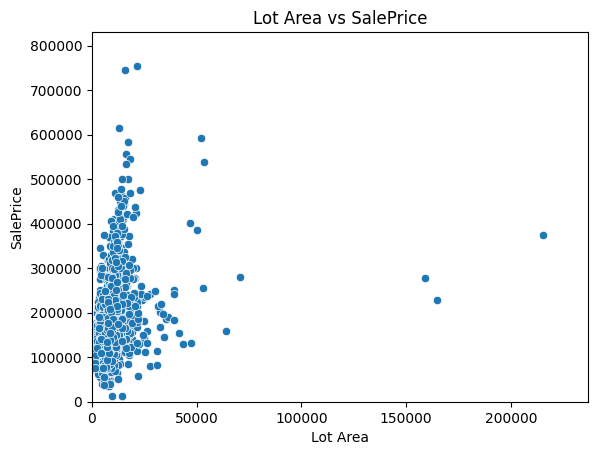

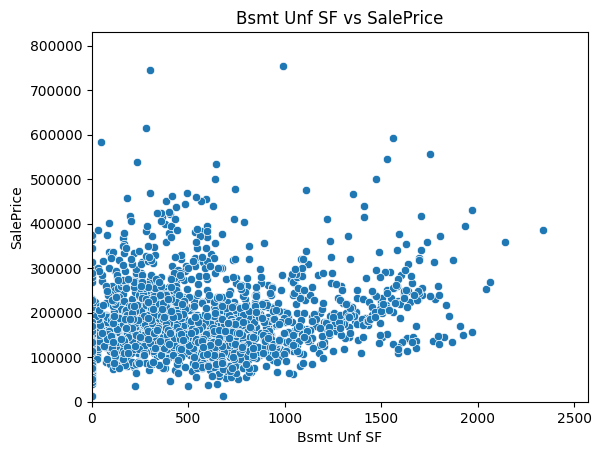

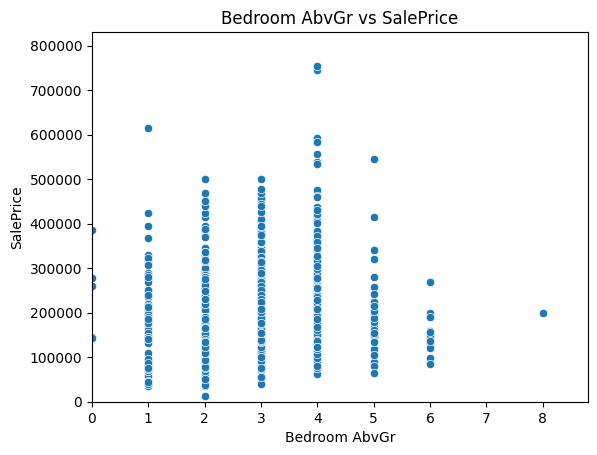

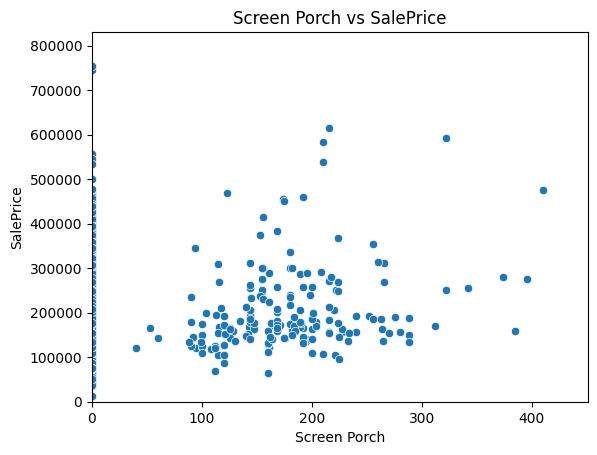

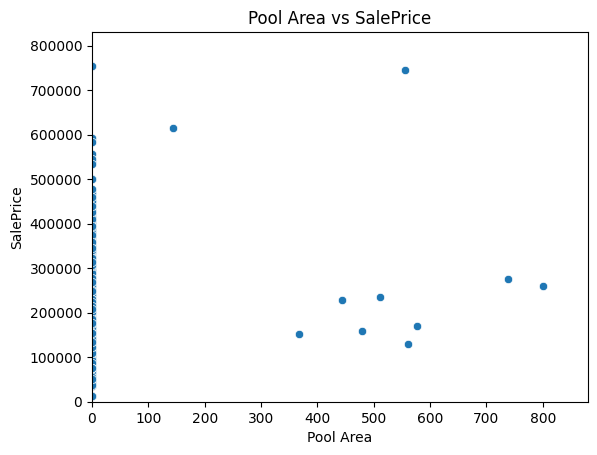

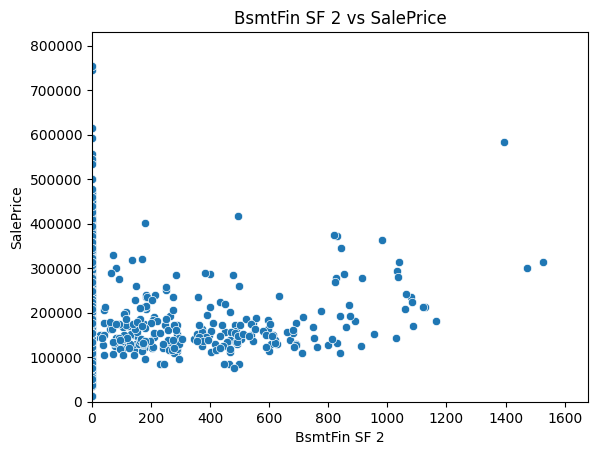

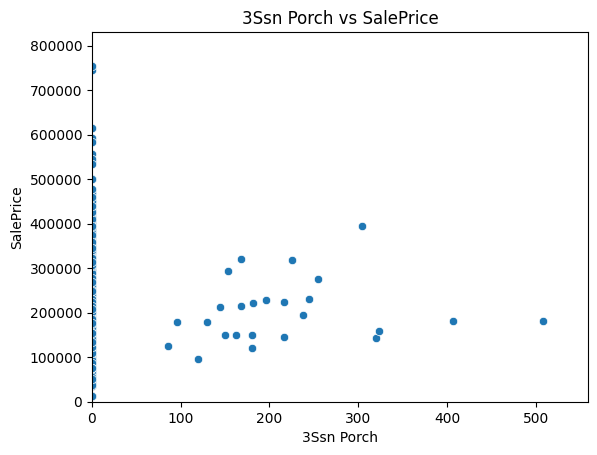

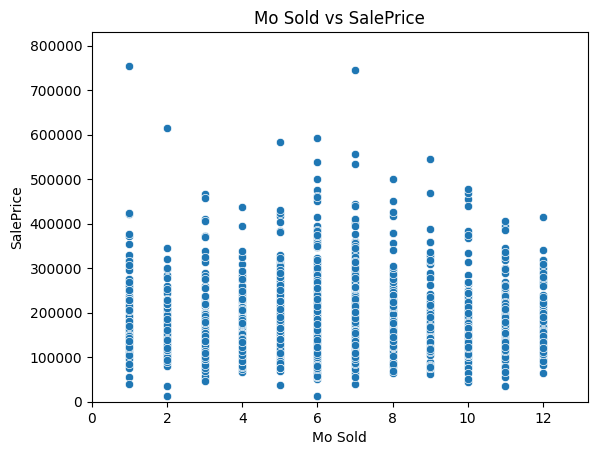

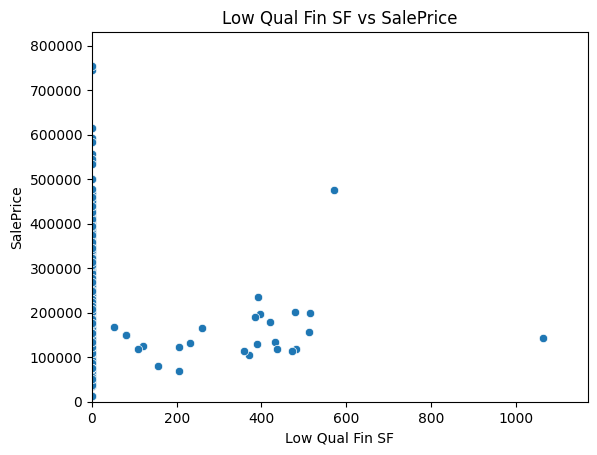

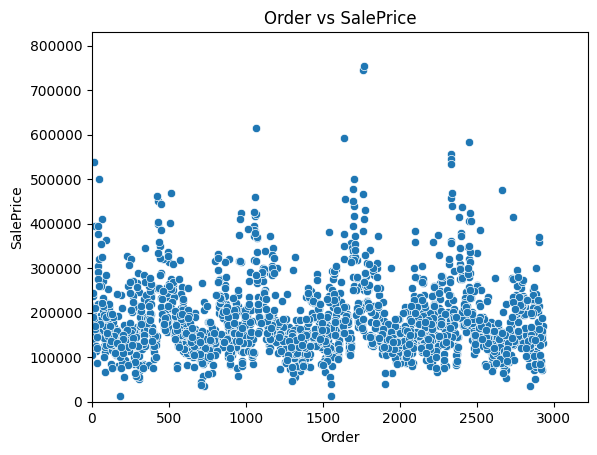

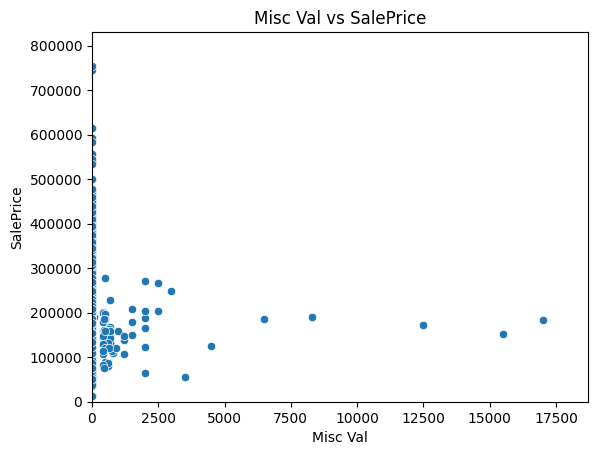

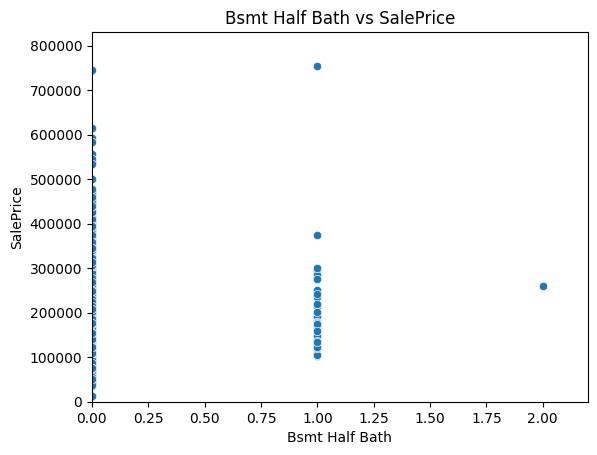

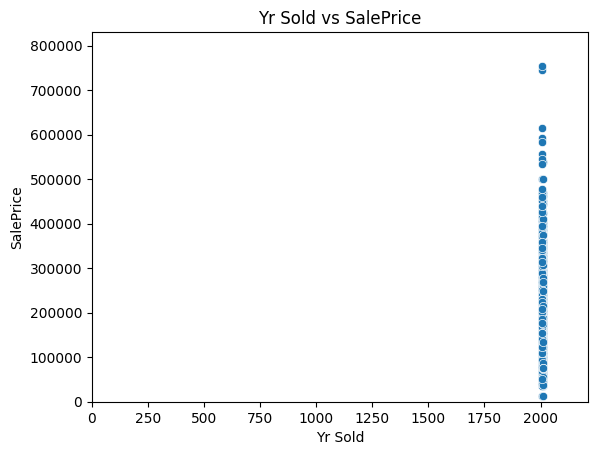

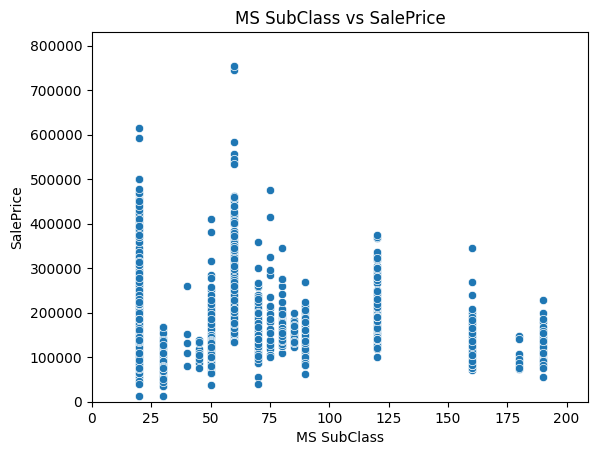

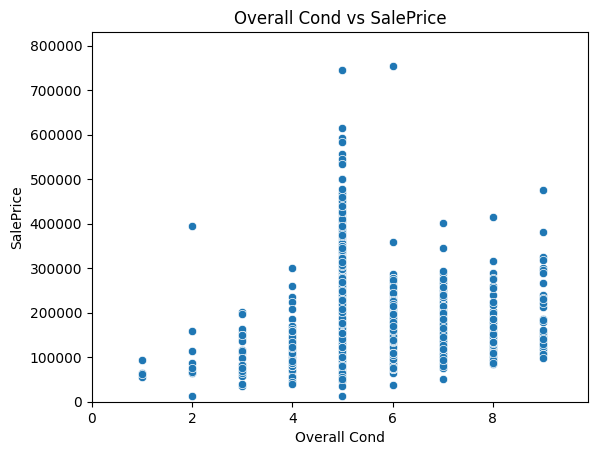

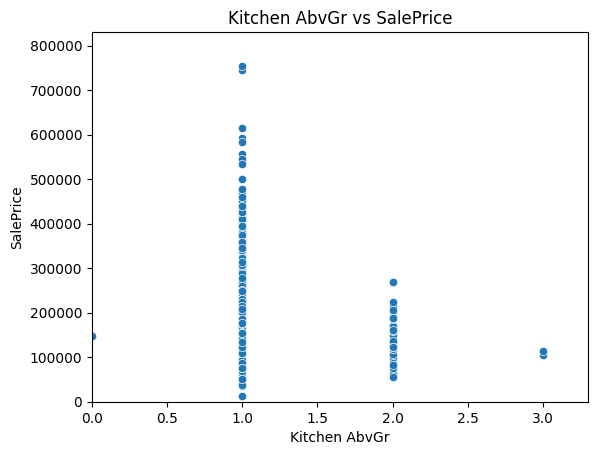

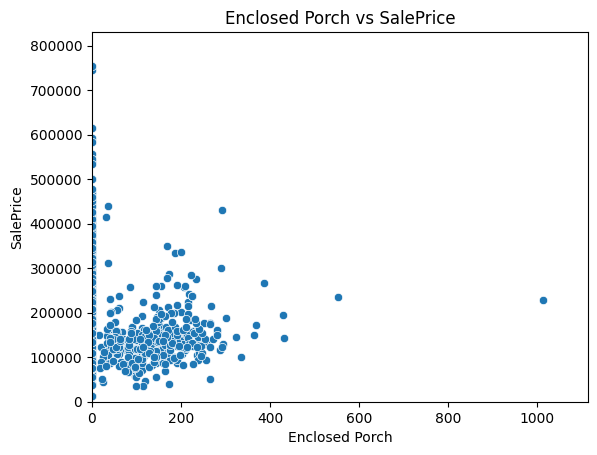

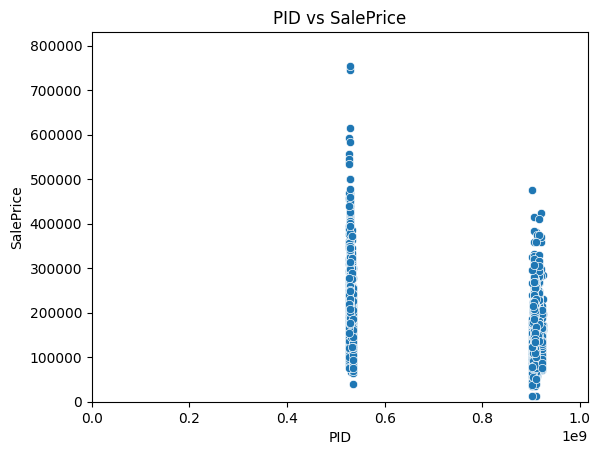

In [136]:
for col in pd.DataFrame(corr_target).T.columns:
    if df[col].dtype in ['int64', 'float64']:
        plt.figure()
        sns.scatterplot(x=df[col], y=df['SalePrice'])
        plt.xlim(0, df[col].max() * 1.1)  # Define o limite inferior do eixo x como 0 e o superior como um pouco acima do valor máximo da coluna
        plt.ylim(0, df['SalePrice'].max() * 1.1)  # Define o limite inferior do eixo y como 0 e o superior como um pouco acima do valor máximo de SalePrice
        plt.title(f"{col} vs SalePrice")
        plt.xlabel(col)
        plt.ylabel('SalePrice')
        plt.show()

    

In [137]:
df.corr(method='spearman', numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice          1.00
Overall Qual       0.80
Gr Liv Area        0.71
Garage Cars        0.69
Year Built         0.66
Garage Area        0.64
Full Bath          0.63
Garage Yr Blt      0.61
Total Bsmt SF      0.59
Year Remod/Add     0.58
1st Flr SF         0.57
Fireplaces         0.52
TotRms AbvGrd      0.49
Open Porch SF      0.46
Lot Area           0.42
Mas Vnr Area       0.42
Lot Frontage       0.38
Wood Deck SF       0.36
Half Bath          0.35
BsmtFin SF 1       0.33
Bsmt Full Bath     0.27
2nd Flr SF         0.26
Bedroom AbvGr      0.21
Bsmt Unf SF        0.14
Screen Porch       0.11
Pool Area          0.05
3Ssn Porch         0.05
Mo Sold            0.05
MS SubClass        0.03
BsmtFin SF 2      -0.01
Bsmt Half Bath    -0.01
Order             -0.02
Yr Sold           -0.03
Low Qual Fin SF   -0.04
Misc Val          -0.06
Kitchen AbvGr     -0.13
Overall Cond      -0.16
Enclosed Porch    -0.24
PID               -0.26
Name: SalePrice, dtype: float64

### Categóricas X Target

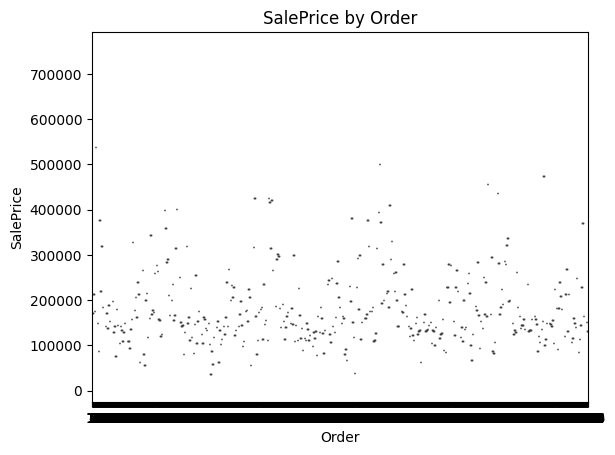

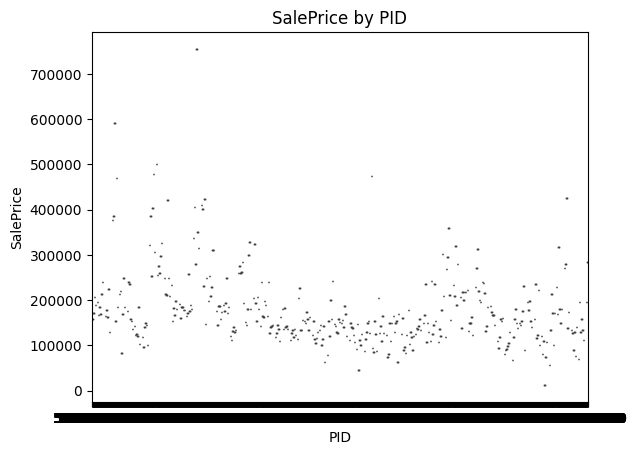

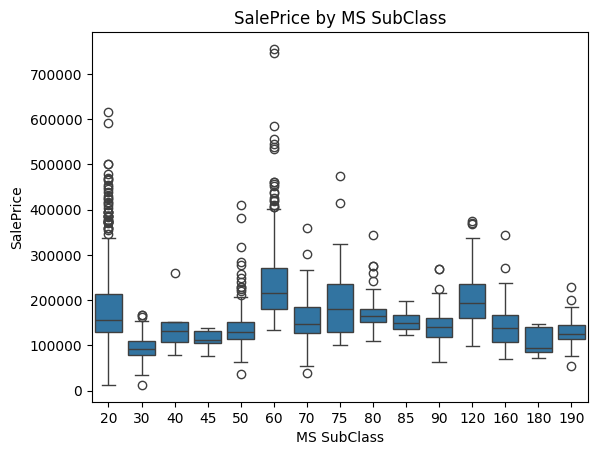

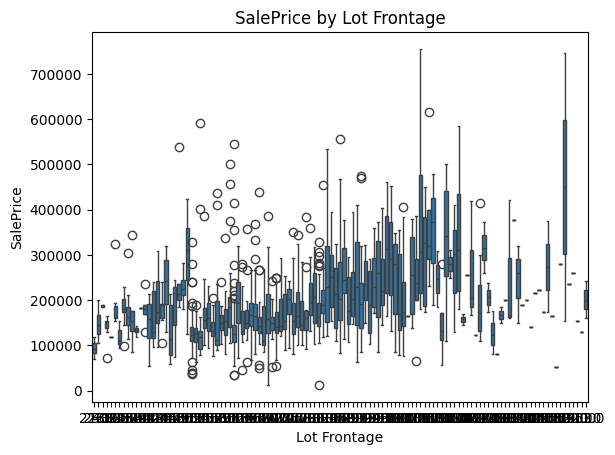

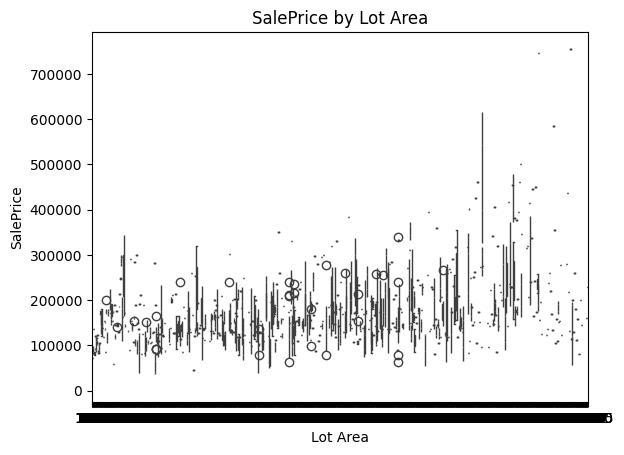

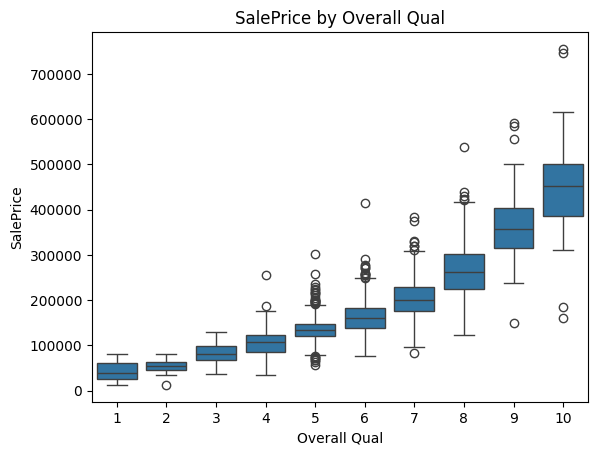

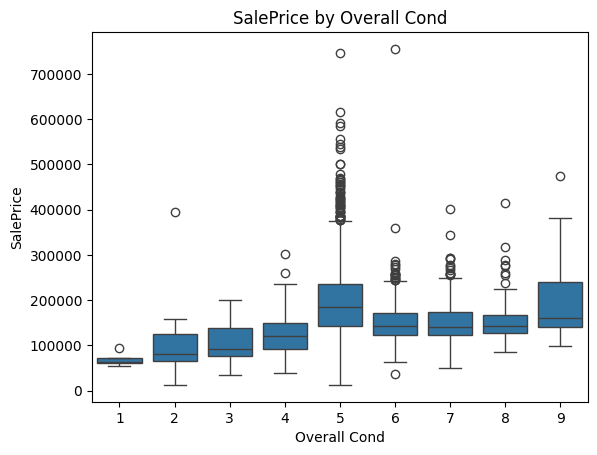

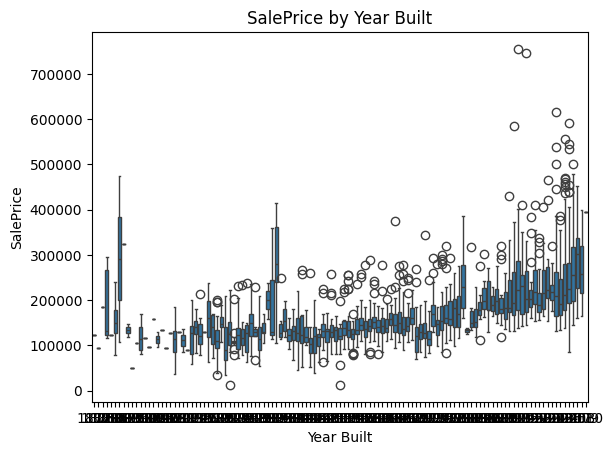

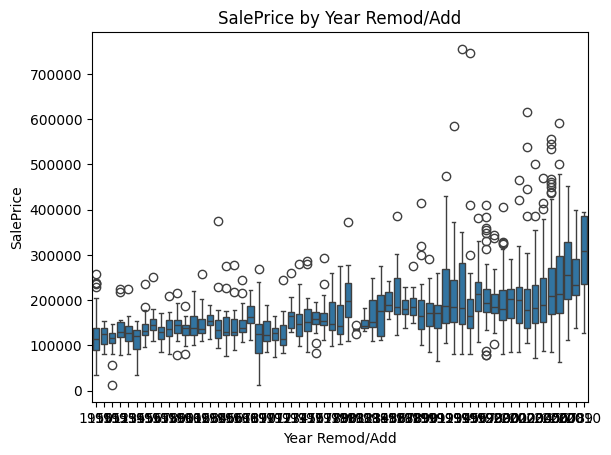

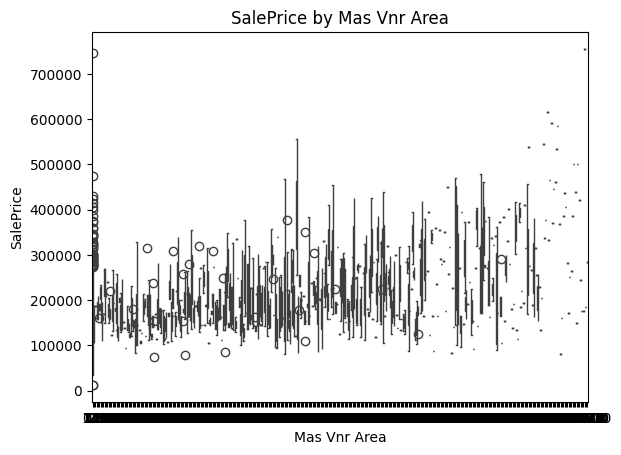

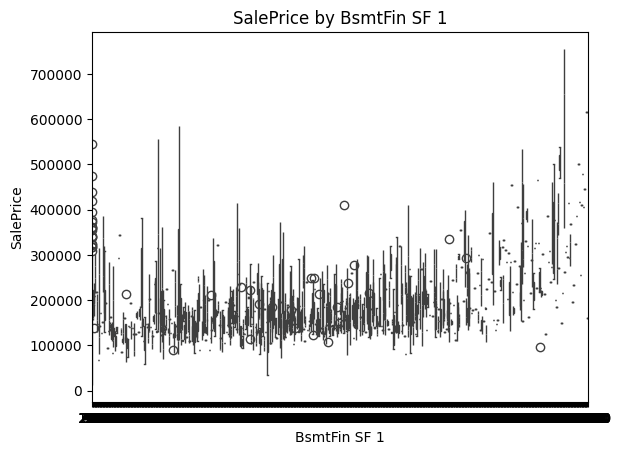

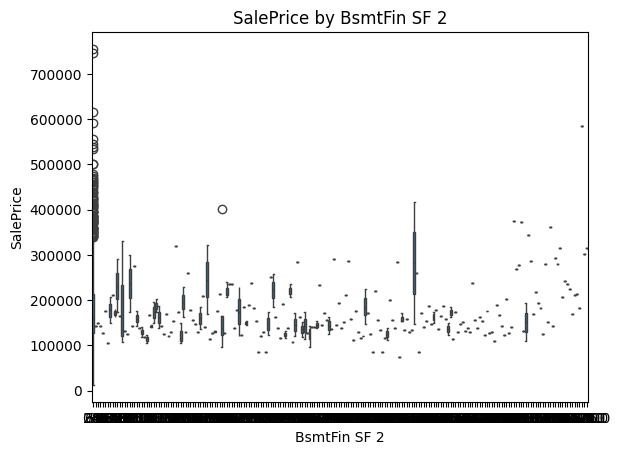

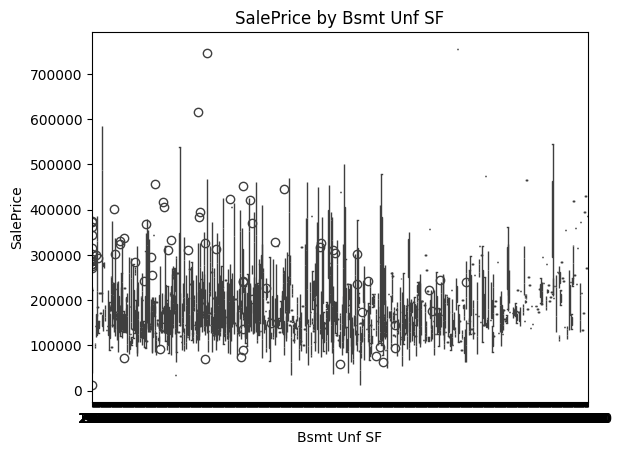

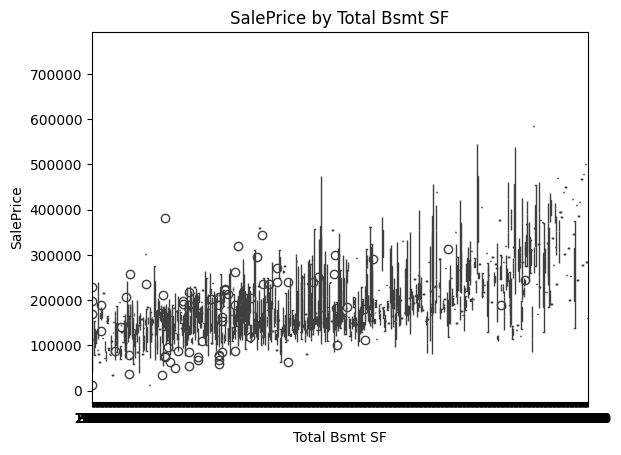

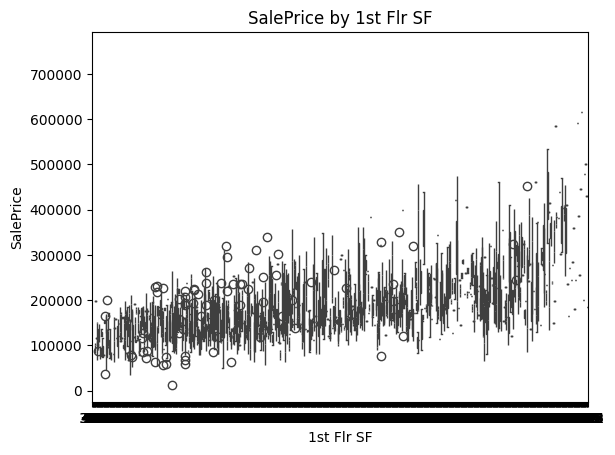

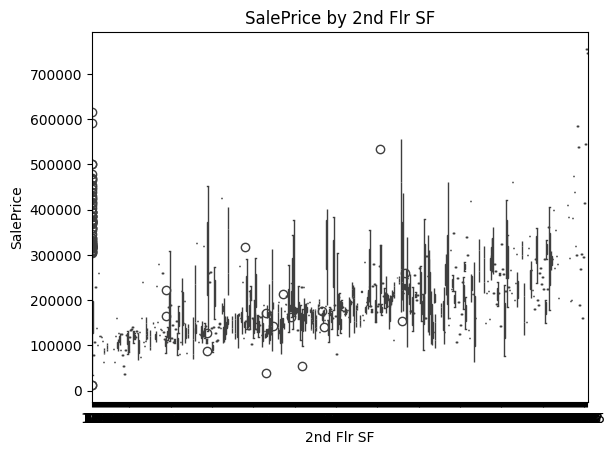

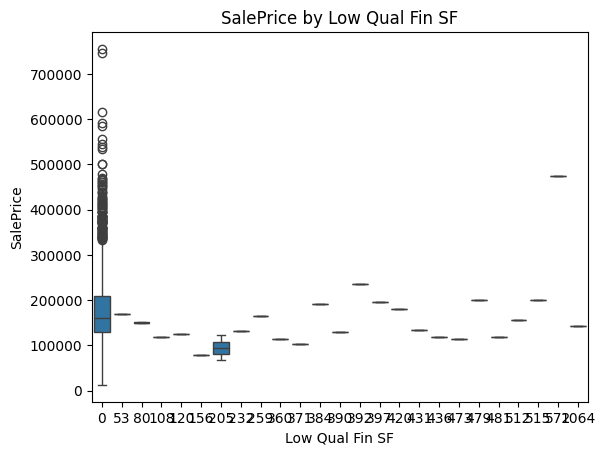

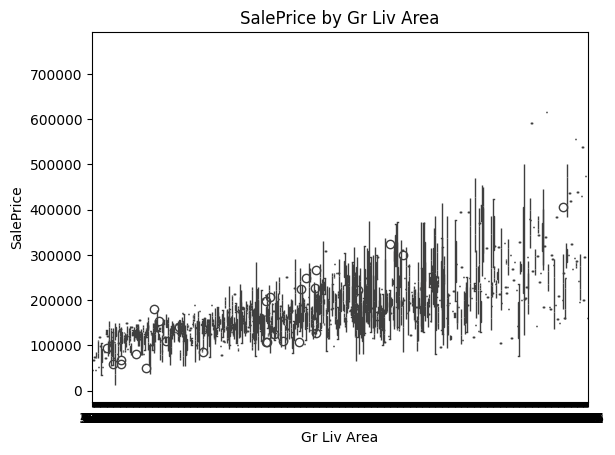

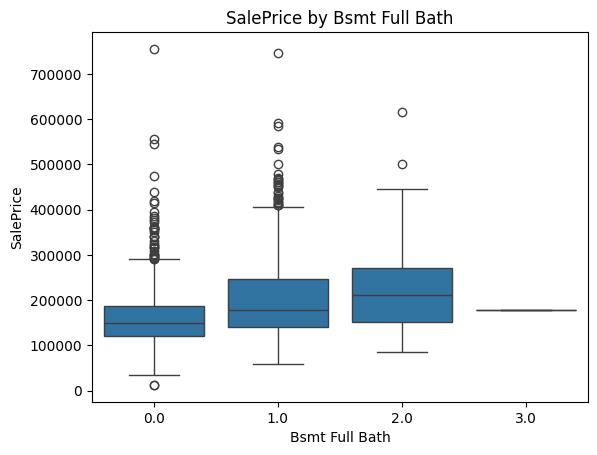

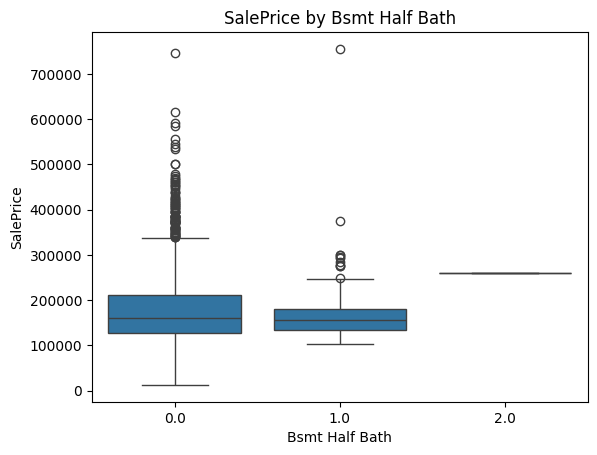

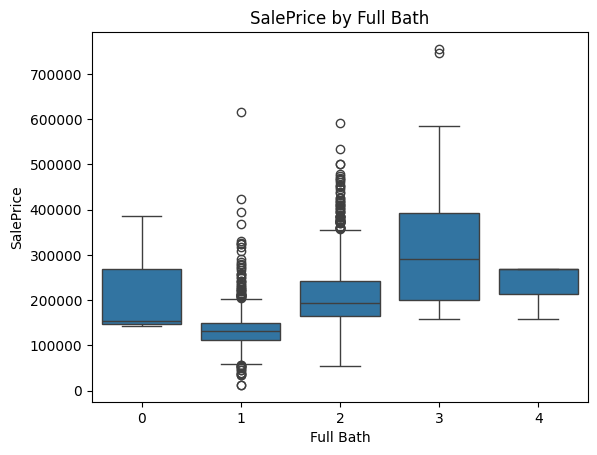

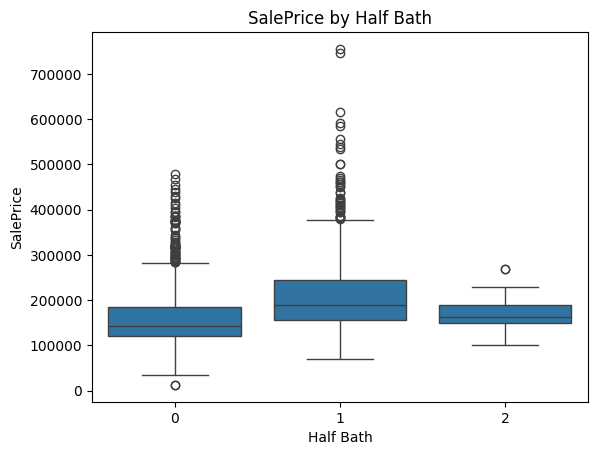

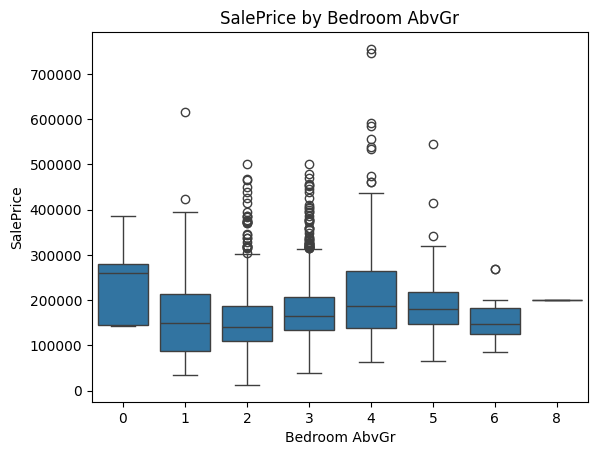

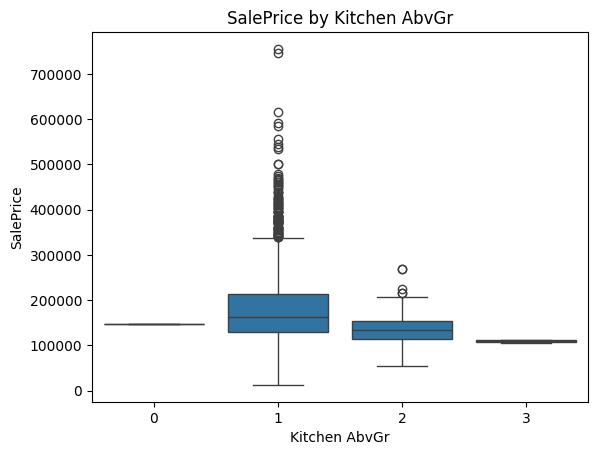

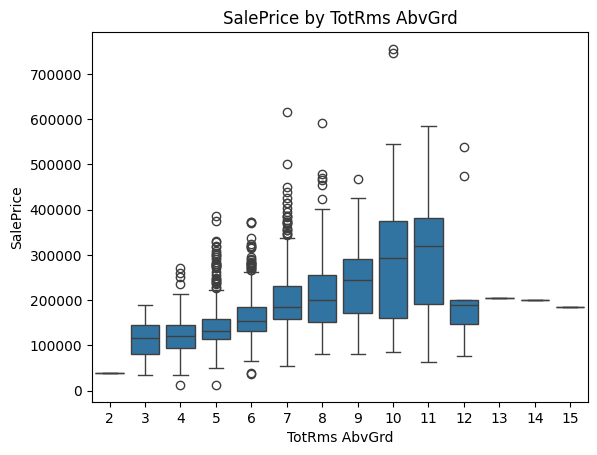

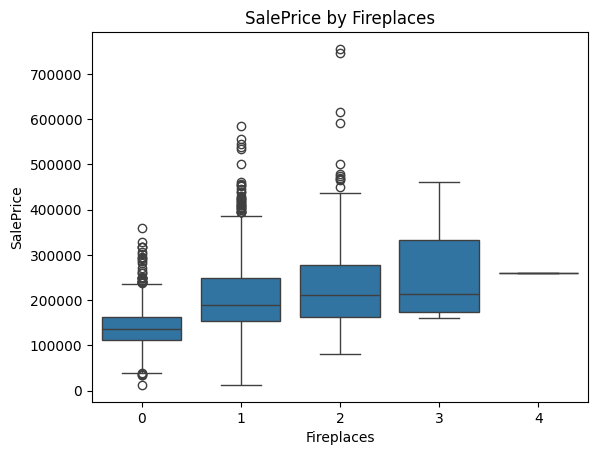

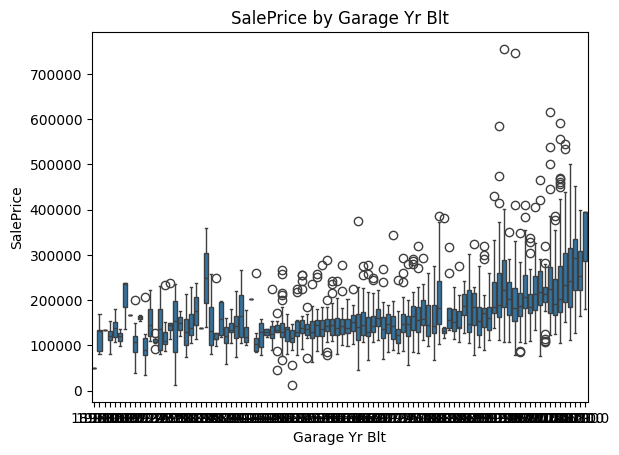

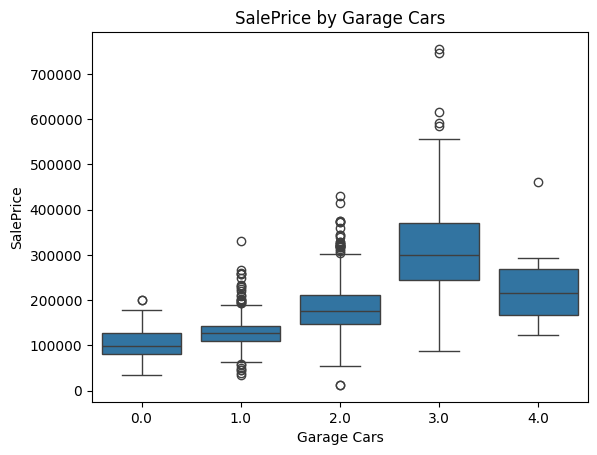

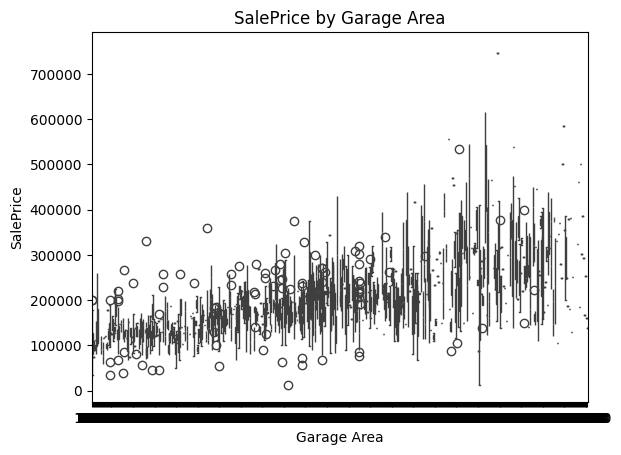

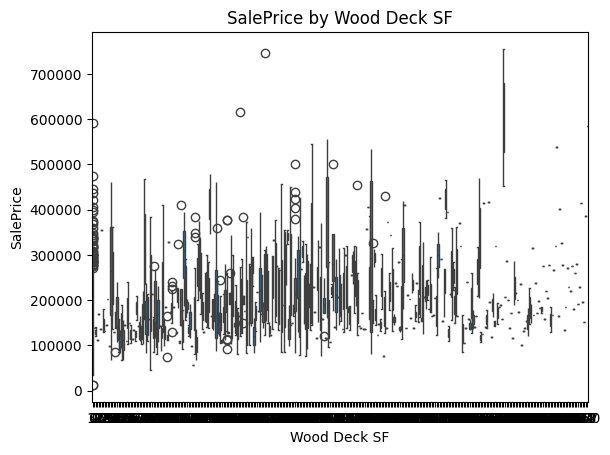

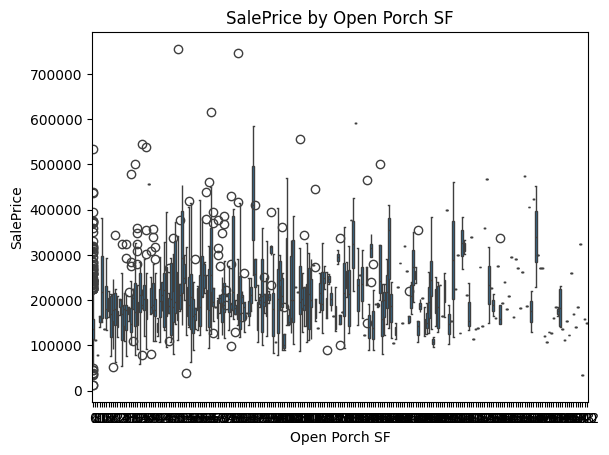

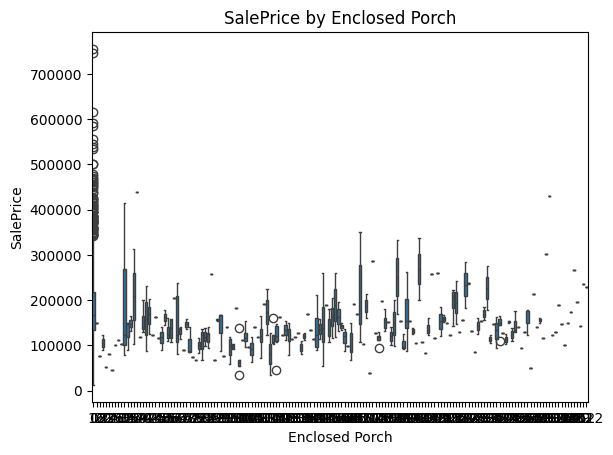

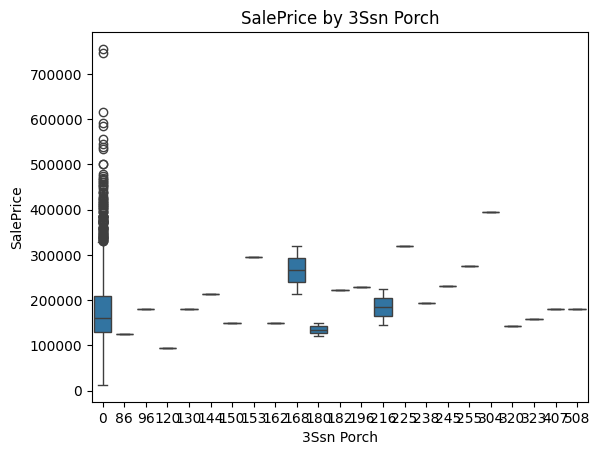

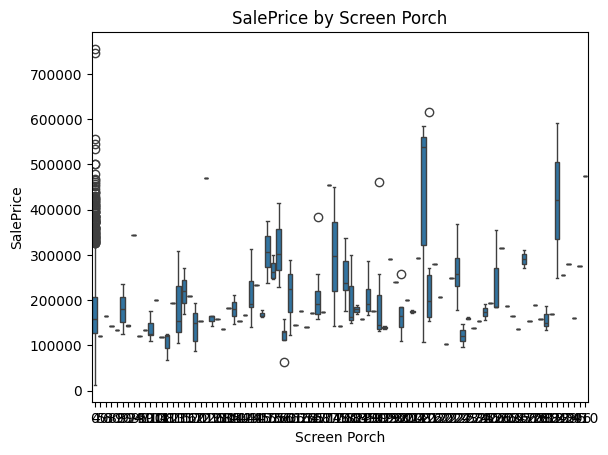

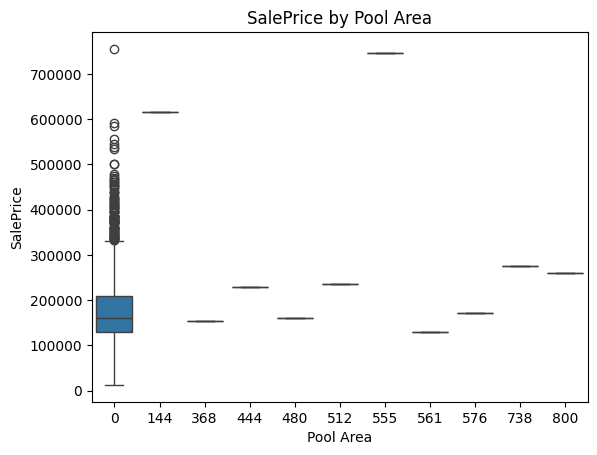

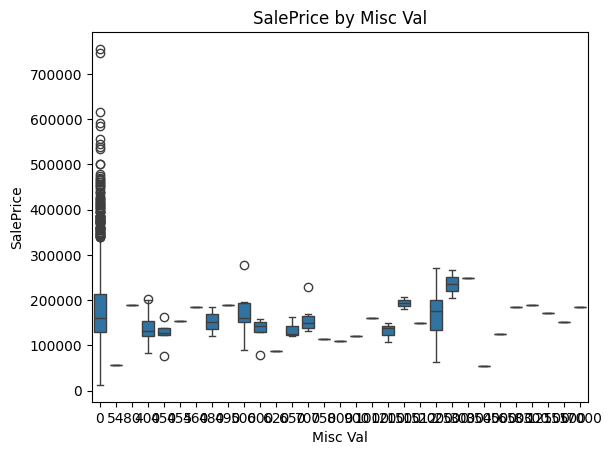

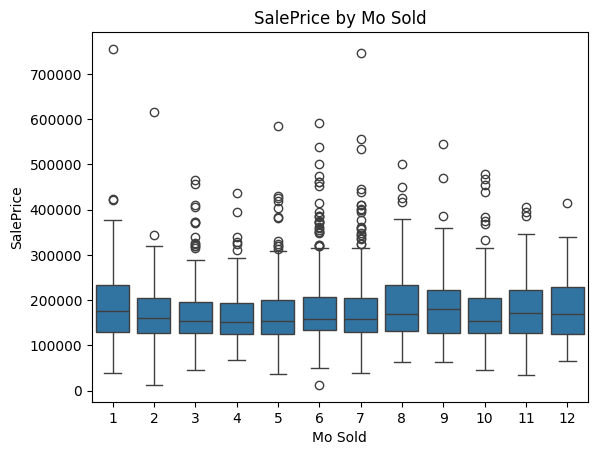

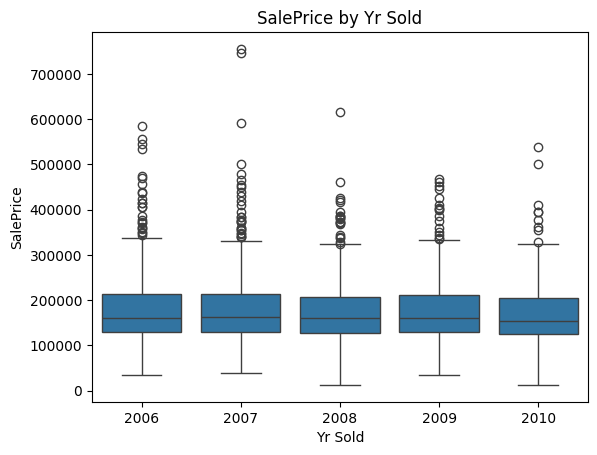

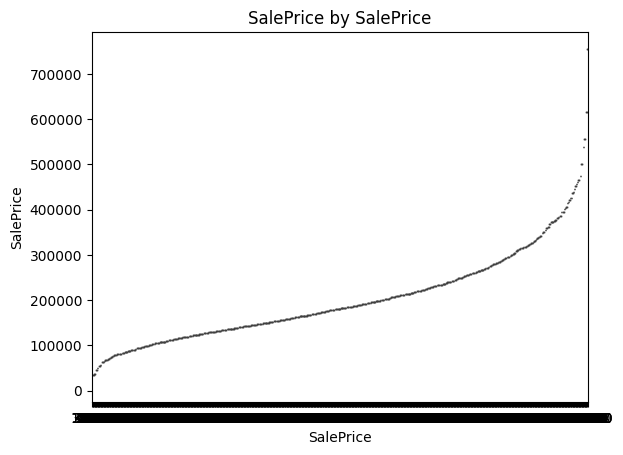

In [138]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(data=df, x=col, y='SalePrice')
    plt.title("SalePrice by " + col)
    plt.show()